In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# GDS factrory imports
import gdsfactory as gf
from gdsfactory.typings import Layer

# NOTE: In GDS factory all dimensions are in um. --> except the onces that aren't. backbone and overlap extractions are in nm for some reason. 

# Thermocouple PDK
Process Design Kit: Layer Stack

| Layer | Material | Purpose                                                |
|-------|----------|--------------------------------------------------------|
| (1,0) | Cr       | Alignment Markers / Adhesion                           |
| (2,0) | Au       | Active Layer, Plasmonic layer                          |
| (3,0) | Au fast  | BIG STRUCTURES                                         |
| (4,0) | Ni       | BIG STRUCTURES                                         |
| (5,0) | Ni       | TC structures                                          |
| (n,0) | Ni       | Further Thickness Ni layers for multi thickness arrays |

A PDK is a collection of pre-defined components, layers, and design rules for a specific manufacturing process.


In [2]:
class TFTClayers(gf.technology.LayerMap):
    """Thin Film Thermocouple Materials & layer stack"""

    CR_ALIGN: Layer = (1, 0)         # Chromium alignment markers / adhesion layer
    AU_ACTIVE: Layer = (2, 0)        # Gold active plasmonic element layer
    AU_LARGE: Layer = (3, 0)         # Wide gold BIG STRUCTURES
    NI_LARGE: Layer = (4, 0)         # Wide nickel BIG STRUCTURES (faster to raster with bigger resolution tolerances)
    NI_TC: Layer = (5, 0)            # Nickel TC structures

    # Additional Ni thickness layers for multi-thickness arrays
    NI_T1: Layer = (6, 0)
    NI_T2: Layer = (7, 0)
    NI_T3: Layer = (8, 0)
    NI_T4: Layer = (9, 0)
    NI_T5: Layer = (10, 0)
    NI_T6: Layer = (11,0)
    NI_T7: Layer = (12,0)
    NI_T8: Layer = (13,0)

    # Boundaries / Label / Prot Vis / Device layers 
    FLOORPLAN: Layer = (64, 0)
    TEXT: Layer = (65, 0)
    PORT: Layer = (66,0)
    DEVREC: Layer = (67,0)           # little box around my array
    KEEP_OUT: Layer = (68,0)         # make some space around contact pads
    
TFTClayers.KEEP_OUT

<TFTClayers.KEEP_OUT: 33>

In [3]:
# defining metal layers (thickness etc in microns)
t_Cr = 5e-3
t_Au = 40e-3
t_Ni = 20e-3
t_Ni_t1 = 25e-3
t_Ni_t2 = 30e-3
t_Ni_t3 = 35e-3
t_Ni_t4 = 40e-3
t_Ni_t5 = 45e-3
t_Ni_t6 = 50e-3
t_Ni_t7 = 55e-3
t_Ni_t8 = 60e-3

# Logical GDS layers
Cr_layer = gf.technology.LogicalLayer(layer=TFTClayers.CR_ALIGN)
Au_layer = gf.technology.LogicalLayer(layer=TFTClayers.AU_ACTIVE)
Ni_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_TC)
Au_layer_large = gf.technology.LogicalLayer(layer=TFTClayers.AU_LARGE)
Ni_layer_large = gf.technology.LogicalLayer(layer=TFTClayers.NI_LARGE)
Ni_t1_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T1)
Ni_t2_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T2)
Ni_t3_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T3)
Ni_t4_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T4)
Ni_t5_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T5)
Ni_t6_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T6)
Ni_t7_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T7)
Ni_t8_layer = gf.technology.LogicalLayer(layer=TFTClayers.NI_T8)

# Physical layer stack
layers = {
    # Cr / Au / Ni layers
    "Cr": gf.technology.LayerLevel(layer=Cr_layer, thickness=t_Cr, zmin=0, material="cr"),
    "Au": gf.technology.LayerLevel(layer=Au_layer, thickness=t_Au, zmin=0, material="au"),
    "Ni": gf.technology.LayerLevel(layer=Ni_layer, thickness=t_Ni, zmin=0, material="ni"),

    # large structure Au / Ni layers
    "Au_large": gf.technology.LayerLevel(layer=Au_layer_large, thickness=t_Au, zmin=0, material="au"),
    "Ni_large": gf.technology.LayerLevel(layer=Ni_layer_large, thickness=t_Ni, zmin=0, material="ni"),
    
    # Increasing thickness nickel layers
    "Ni_t1": gf.technology.LayerLevel(layer=Ni_t1_layer, thickness=t_Ni_t1, zmin=0, material="ni"),
    "Ni_t2": gf.technology.LayerLevel(layer=Ni_t2_layer, thickness=t_Ni_t2, zmin=0, material="ni"),
    "Ni_t3": gf.technology.LayerLevel(layer=Ni_t3_layer, thickness=t_Ni_t3, zmin=0, material="ni"),
    "Ni_t4": gf.technology.LayerLevel(layer=Ni_t4_layer, thickness=t_Ni_t4, zmin=0, material="ni"),
    "Ni_t5": gf.technology.LayerLevel(layer=Ni_t5_layer, thickness=t_Ni_t5, zmin=0, material="ni"),
    "Ni_t6": gf.technology.LayerLevel(layer=Ni_t6_layer, thickness=t_Ni_t6, zmin=0, material="ni"),
    "Ni_t7": gf.technology.LayerLevel(layer=Ni_t7_layer, thickness=t_Ni_t7, zmin=0, material="ni"),
    "Ni_t8": gf.technology.LayerLevel(layer=Ni_t8_layer, thickness=t_Ni_t8, zmin=0, material="ni"),
}

tftc_layer_stack = gf.technology.LayerStack(layers=layers)

In [4]:
tftc_layer_stack.get_layer_to_info()

{CR_ALIGN: {},
 AU_ACTIVE: {},
 NI_TC: {},
 AU_LARGE: {},
 NI_LARGE: {},
 NI_T1: {},
 NI_T2: {},
 NI_T3: {},
 NI_T4: {},
 NI_T5: {},
 NI_T6: {},
 NI_T7: {},
 NI_T8: {}}

In [5]:
# Generic metal routing. Could split this for each metals but dont know if i need to. 
@gf.cross_section.xsection
def tftc_metal_route(width: float = 100, layer=TFTClayers.AU_ACTIVE, **kwargs):
    return gf.cross_section.cross_section(
        width=width,
        layer=layer,
        port_names=("e1", "e2"),
        port_types=("electrical", "electrical"),
        radius=None,          # metal routing uses sharp corners, no bend radius --> We no do RF here. 
        **kwargs,
    )

In [6]:
# Define PDK and activate 
generic_pdk = gf.gpdk.get_generic_pdk()

tftc_pdk = gf.Pdk(
    name="TFTC_array",
    layers=TFTClayers,
    base_pdks=[generic_pdk],
    layer_views=generic_pdk.layer_views,
    layer_stack=tftc_layer_stack,
)

# register the cross section so it can be called with route_single / route_bundle
tftc_pdk.register_cross_sections(tftc_metal_route=tftc_metal_route)

tftc_pdk.activate()

/Users/ciaran/PhD/github/Photolithography/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3748: UserWarning: Overwriting cross_section 'tftc_metal_route'
  exec(code_obj, self.user_global_ns, self.user_ns)


# Defining Component cells used to build the array

Define the active region in which to litho. 

In [7]:
# 15 mm x 15 mm area usable on slide. 
@gf.cell
def die(
    size: gf.typings.Size = (10000.0, 10000.0),
    street_width: float = 100.0,
    street_length: float = 1000.0,
    die_name: str | None = "chip99",
    text_size: float = 100.0,
    text_location: str | gf.typings.Float2 = "SW",
    layer: gf.typings.LayerSpec | None = "FLOORPLAN",
    bbox_layer: gf.typings.LayerSpec | None = "FLOORPLAN",
    text: gf.typings.ComponentSpec = "text",
    draw_corners: bool = False,
) -> gf.Component:
    """Returns die with optional markers marking the boundary of the die.

    Args:
        size: x, y dimensions of the die.
        street_width: Width of the corner marks for die-sawing.
        street_length: Length of the corner marks for die-sawing.
        die_name: Label text. If None, no label is added.
        text_size: Label text size.
        text_location: {'NW', 'N', 'NE', 'SW', 'S', 'SE'} or (x, y) coordinate.
        layer: For street widths. None to not draw the street widths.
        bbox_layer: optional bbox layer drawn bounding box around the die.
        text: function use for generating text. Needs to accept text, size, layer.
        draw_corners: True draws only corners. False draws a square die.
    """
    c = gf.Component()
    sx, sy = size[0] / 2, size[1] / 2

    if layer:
        if not draw_corners:
            street_length = sx
        xpts = np.array(
            [
                sx,
                sx,
                sx - street_width,
                sx - street_width,
                sx - street_length,
                sx - street_length,
            ]
        )
        if not draw_corners:
            street_length = sy
        ypts = np.array(
            [
                sy,
                sy - street_length,
                sy - street_length,
                sy - street_width,
                sy - street_width,
                sy,
            ]
        )
        c.add_polygon(list(zip(xpts, ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(-xpts, ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(xpts, -ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(-xpts, -ypts, strict=False)), layer=layer)

    if bbox_layer:
        c.add_polygon([(sx, sy), (sx, -sy), (-sx, -sy), (-sx, sy)], layer=bbox_layer)

    if die_name:
        text_component = gf.get_component(
            text, text=die_name, size=text_size, layer="TEXT"
        )
        t = c.add_ref(text_component)

        d = street_width + 20
        if isinstance(text_location, str):
            text_location = text_location.upper()
            if text_location == "N":
                t.x, t.ymax = [0, sy - d]
            elif text_location == "NE":
                t.xmax, t.ymax = [sx - d, sy - d]
            elif text_location == "NW":
                t.xmin, t.ymax = [-sx + d, sy - d]
            elif text_location == "S":
                t.x, t.ymin = [0, -sy + d]
            elif text_location == "SE":
                t.xmax, t.ymin = [sx - d, -sy + d]
            elif text_location == "SW":
                t.xmin, t.ymin = [-sx + d, -sy + d]
            else:
                raise ValueError(
                    f"Invalid text_location: {text_location} not in N, NE, NW, S, SE, SW"
                )
        else:
            t.x, t.y = text_location

    return c

# Example
# gf.clear_cache()
# sample_die = die()
# sample_die.plot()

Define the contact pad thatI will wire bond to. 

In [8]:
# 0.5 mm x 0.5 mm contact pad.
@gf.cell
def contact_pad(
    size: gf.typings.Size = (500.0, 500.0),
    layer: gf.typings.LayerSpec = TFTClayers.AU_ACTIVE, # NOTE: Default layer should be changed for each usage to specific layer in structure!
    port_width: float = 10.0,
    port_orientation: float = 0.0, # 0=Right, 90=Top, 180=Left, 270=Bottom
) -> gf.Component:
    """Returns a square/rectangular contact pad with a connection port.

    Args:
        size: Width (x) and height (y) dimensions of the contact pad.
        layer: GDS layer for the pad metal.
        port_width: Width of the trace connection track port.
        port_orientation: Angle of the port facing direction in degrees.
    """
    c = gf.Component()
    sx, sy = size[0] / 2.0, size[1] / 2.0

    # 1. Draw the main square pad centered at (0, 0)
    c.add_polygon(
        [(-sx, -sy), (sx, -sy), (sx, sy), (-sx, sy)], 
        layer=layer
    )

    # 2. Add an optical/electrical port for track routing
    # We position the port precisely on the edge based on user orientation
    if port_orientation == 0.0:     # Right edge
        port_center = (sx, 0.0)
    elif port_orientation == 90.0:   # Top edge
        port_center = (0.0, sy)
    elif port_orientation == 180.0:  # Left edge
        port_center = (-sx, 0.0)
    elif port_orientation == 270.0:  # Bottom edge
        port_center = (0.0, -sy)
    else:
        # Fallback to center if a custom angle is input
        port_center = (0.0, 0.0)

    c.add_port(
        name="e1",                  # Port identifier name
        center=port_center,         # Exact connection point coordinate
        width=port_width,           # Matches your interconnect wire track width
        orientation=port_orientation, 
        layer=layer,
        port_type="electrical"      # Specifies this is for conductive paths
    )

    return c

# Example
# gf.clear_cache()
# cps = contact_pad()
# cps.plot()

Thermocouple junction cell. Variable square overlap size but chiral leg design with variable left/right leg length. 

In [9]:
@gf.cell
def thermocouple_junction(
    w: float = 3.0,                  # Overlap width (square overlap)
    layer_bottom: gf.typings.LayerSpec = TFTClayers.AU_ACTIVE, # Au Bottom Layer
    layer_top: gf.typings.LayerSpec = TFTClayers.NI_TC,    # Ni Top Layer
    text = True,
    offset_leg_l1 = 0,
    offset_leg_l2 = 0,
    port_orientation = 0,
    port_width=100,
) -> gf.Component:
    """Returns a scalable chiral thermocouple junction.
    
    The geometry scales dynamically based on the parameter `w`.
    Maintains a perfect vertical overlap contact zone at the center.
    """
    c = gf.Component()

    # 1. Generate parameterized coordinates based on 'w'
    coords_layer1 = [
        (0.0, 0.0 - offset_leg_l1),
        (0.0, 2 * w),
        (2 * w, 2 * w),
        (2 * w, w),
        (w, w),
        (w, 0.0 - offset_leg_l1),
        
    ]

    # Mirror horizontally and shift by 3*w to sit the chiral edge perfectly 
    # on the original (2*w, w) -> (w, w) segment.
    coords_layer2 = [(-x + 3 * w, y) for x, y in coords_layer1]
    # Adding offset on the legs for layer 2.
    # have to add offset l1 back because its copied from coords_layer1!!!!
    coords_layer2[0] = (coords_layer2[0][0], coords_layer2[0][1] - offset_leg_l2 + offset_leg_l1)
    coords_layer2[-1] = (coords_layer2[-1][0], coords_layer2[-1][1] - offset_leg_l2 + offset_leg_l1)

    # 2. Add Polygons
    c.add_polygon(coords_layer1, layer=layer_bottom)
    c.add_polygon(coords_layer2, layer=layer_top)

    # 3. Add Dynamic Labels centered in the non-overlapped vertical legs
    # Left leg center: X = 0.5*w, Y = 1.0*w
    if text:
        c.add_label(text="Au_Bottom_Layer", position=(0.35 * w, 1.0 * w), layer=layer_bottom)
    
        # Right leg center: X = 2.5*w, Y = 1.0*w
        c.add_label(text="Ni_Top_Layer", position=(2.35 * w, 1.0 * w), layer=layer_top)
        
        # Header label centered above the central junction area
        c.add_label(text=f"{int(w)}x{int(w)} Thermocouple", position=(1.5 * w, 2.2 * w), layer=(0, 0))

    # 4. Add Electrical Ports for easy track routing
    if port_orientation == 0:
        c.add_port(
            name="e1_gold",
            center=(0,-offset_leg_l1+port_width/2),
            width=w,
            orientation=180,
            layer=layer_bottom,
            port_type="electrical"
        )
        
        c.add_port(
            name="e2_nickel",
            center=(2 * w, -offset_leg_l2+port_width/2),
            width=w,
            orientation=180,
            layer=layer_top,
            port_type="electrical"
        )
        
    elif port_orientation == 180:
        c.add_port(
            name="e1_gold",
            center=(w,-offset_leg_l1+port_width/2),
            width=w,
            orientation=0,
            layer=layer_bottom,
            port_type="electrical"
        )
        
        c.add_port(
            name="e2_nickel",
            center=(3 * w, -offset_leg_l2+port_width/2),
            width=w,
            orientation=0,
            layer=layer_top,
            port_type="electrical"
        )

    return c

# Example
# gf.clear_cache()
# tcj = thermocouple_junction()
# tcj.plot()

Active region with contact pads. Probably wont use this version but rather build both as above. 

In [10]:
@gf.cell
def die_with_pads(
    die_size: tuple[float, float] = (15000.0, 15000.0),
    contactpad_size: float = 750.0,
    port_width: float = 100.0,
) -> gf.Component:
    """Returns a 15mm die frame populated with 24 custom contact pads along its edges."""
    
    # 1. Initialize the main container component
    c = gf.Component()

    # 2. Create and add the Frame
    frame_cell = die(
        size=die_size,
        street_width=150,         
        die_name="15mm_ActiveRegion", 
        text_location="SW",
        layer="FLOORPLAN",
        bbox_layer="FLOORPLAN",
        draw_corners=False        
    )
    c.add_ref(frame_cell)

    # 3. Generate the pad dictionary dynamically
    port_dict = {}
    for i in range(1, 25):
        if i <= 2:
            layer = (1, 0)
            orientation = 0.0
        elif i < 8:
            layer = ((i + 1) % 2 + 1, 0)
            orientation = 0.0
        elif i < 18:
            layer = ((i + 1) % 2 + 1, 0)
            orientation = 90.0
        else:
            layer = ((i + 1) % 2 + 1, 0)
            orientation = 180.0
            
        port_dict[f"cp{i}"] = contact_pad(
            size=(contactpad_size, contactpad_size), 
            layer=layer, 
            port_width=port_width, 
            port_orientation=orientation
        )

    # 4. Clearances and offsets for placement
    side_clearance = round((11000 - 7 * contactpad_size) / 6)
    bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
    bottom_x_offset = -5500
    side_y_offset = 5500

    # 5. Place the references into the component
    for i in range(1, 25):
        ref = c << port_dict[f"cp{i}"]

        # Spreading the contact pads along Left, Bottom, and Right sides
        if i < 8:
            ref.center = (
                -die_size[0]/2 + 1.5 * contactpad_size, 
                side_y_offset - (side_clearance + contactpad_size) * (i - 1) - contactpad_size / 2
            )
        elif i < 18: 
            ref.center = (
                bottom_x_offset + (bottom_clearance + contactpad_size) * (i - 8) + contactpad_size / 2, 
                -die_size[1]/2 + 1.5 * contactpad_size
            )
        else:
            ref.center = (
                die_size[0]/2 - 1.5 * contactpad_size, 
                side_y_offset - (side_clearance + contactpad_size) * (i - 18) - contactpad_size / 2
            )
            
        # Optional: Proxy the ports of the pads to the main component cell if needed
        # c.add_ports(ref.ports, prefix=f"pad_{i}_")

    return c

# Example
# gf.clear_cache()
# dwp = die_with_pads()
# dwp.plot()

Calipers for checking alignment between layers. 

In [11]:
@gf.cell
def litho_calipers(
    notch_size=(2.0, 5.0),
    notch_spacing: float = 2.0,
    num_notches: int = 11,
    offset_per_notch: float = 0.1,
    row_spacing: float = 0.0,
    layer1=(1, 0),
    layer2=(2, 0),
) -> gf.Component:
    """Vernier caliper structure to test lithography alignment
    Only the middle finger is aligned and the rest are offset.

    adapted from phidl

    Args:
        notch_size: [xwidth, yheight]
        notch_spacing: 2
        num_notches: 11
        offset_per_notch: 0.1
        row_spacing: 0
        layer1: 1
        layer2: 2

    """

    D = gf.Component()
    num_notches_total = num_notches * 2 + 1
    centre_notch = num_notches
    R1 = gf.components.rectangle(size=notch_size, layer=layer1)
    R2 = gf.components.rectangle(size=notch_size, layer=layer2)
    for i in range(num_notches_total):
        if i == centre_notch:
            D.add_ref(R1).movex(i * (notch_size[0] + notch_spacing)).movey(
                notch_size[1]
            )
            D.add_ref(R2).movex(
                i * (notch_size[0] + notch_spacing)
                + offset_per_notch * (centre_notch - i)
            ).movey(-2 * notch_size[1] - row_spacing)
        D.add_ref(R1).movex(i * (notch_size[0] + notch_spacing))
        D.add_ref(R2).movex(
            i * (notch_size[0] + notch_spacing) + offset_per_notch * (centre_notch - i)
        ).movey(-notch_size[1] - row_spacing)

    _ = (D << gf.components.text(
            text=f"{offset_per_notch} um off-set",
            size=10,
            position=(
                num_notches * (notch_spacing + notch_size[0]),
                notch_size[1] * 2 + 10,
            ),
            justify="center",
            layer=layer1,
        ).copy()
    )
    return D

# Example
# gf.clear_cache()
# lithocal = litho_calipers(notch_size=(5.0, 10.0), notch_spacing=5.0, layer1=(1, 0), layer2=(2, 0))
# lithocal.plot()

Example Thermocouple junction. gf.cell made above based on it. 

# Thermocouple Junction Array (Homogeneous)

Side Pad Spacing: 958 um
Bottom Pad Spacing: 389 um


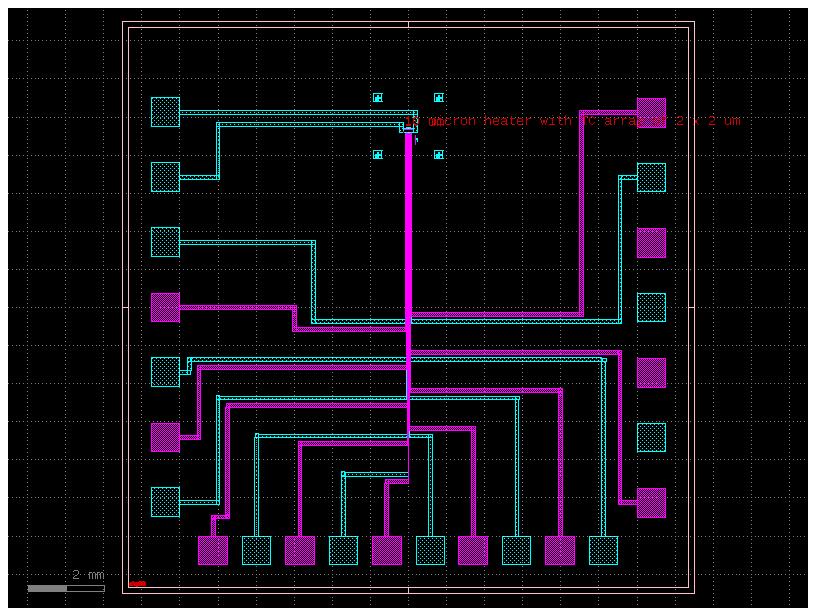

In [45]:
gf.clear_cache()
TC = gf.Component("Example combination of sample TC and Frame")

# ================= Frame ================= #
Frame = die(
    size=(15000, 15000),      # 15 mm x 15 mm
    street_width=150,         
    # die_name="15mm_ActiveRegion", 
    text_location="SW",       # text bottom left
    layer=TFTClayers.FLOORPLAN,
    bbox_layer="FLOORPLAN",
    draw_corners=False        
)
addFrame = TC.add_ref(Frame)

# ================= Contact Pads ================= #

port_dict = {}
contactpad_size = 750

alternate_layers = [TFTClayers.AU_ACTIVE, TFTClayers.NI_TC]
# Generate pad component definitions
for i in range(1, 25):
    if i <= 2: # heater pads
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=TFTClayers.AU_ACTIVE, port_width=100.0, port_orientation=0.0)
    elif i < 8: # every second layer
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=alternate_layers[(i+1) % 2], port_width=100.0, port_orientation=0.0)
    elif i < 18:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=alternate_layers[(i+1) % 2], port_width=100.0, port_orientation=90.0)
    else:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=alternate_layers[(i+1) % 2], port_width=100.0, port_orientation=180.0)
        
side_clearance = round((11000 - 7 * contactpad_size) / 6)
bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
bottom_x_offset = -5500
side_y_offset = 5500

print(f"Side Pad Spacing: {side_clearance} um\nBottom Pad Spacing: {bottom_clearance} um")

# Add pads as references and inherit ports to master component
add_port_dict = {}
for i in range(1, 25):
    ref = TC << port_dict[f"cp{i}"]
    add_port_dict[f"add_cp{i}"] = ref
    
    # Spread the contact pads evenly along each side: (1,7)Left, (8,17)Bottom, (18,24)Right
    if i < 8:
        ref.center = (-7500 + 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-1) - contactpad_size/2)
    elif i < 18: 
        ref.center = (bottom_x_offset + (bottom_clearance + contactpad_size) * (i-8) + contactpad_size/2, -7500 + 1.5 * contactpad_size)
    else:
        # ref.center = (7500 - 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-18) - contactpad_size/2)
        ref.center = (
        7500 - 1.5 * contactpad_size,
        -side_y_offset + (side_clearance + contactpad_size) * (i-18) + contactpad_size/2
    )

    # SUCCESS: Exposing pad ports up to the main master component
    TC.add_ports(ref.ports, prefix=f"pad_{i}_")


# ================= Heater Sub-Component ================= #
single_heater = gf.Component("Single_Heater")
descriptor = "10 micron heater with TC array of 2 x 2 um"

# Define the coordinates of the heater (Layer 1: Au layer)
heater_coords = [
    (-100.0, 0.0),
    (-100.0, 10.0),
    (380.0, 10.0),
    (380, 0),
    (-100, 0)
]

# Add polygon to heater (stepped_heater_coords for stepped heater)
p1 = single_heater.add_polygon(heater_coords, layer=TFTClayers.AU_ACTIVE)

# 10 um port on either side of the heater trace
single_heater.add_port(
    name="v_in",
    center=(-50, 10),
    width=100,
    orientation=90,
    layer=TFTClayers.AU_ACTIVE,
    port_type="electrical"
)

single_heater.add_port(
    name="v_out",
    center=(330, 10),
    width=100,
    orientation=90,
    layer=TFTClayers.AU_ACTIVE,
    port_type="electrical"
)

# ================= Thermocouples Sub-Component ================= #
# Instantiate and space 9 Thermocouple Junctions by 20 um
# separation is just for routing connecting lines (if statements?)
# Making the TC's single layer. To adjust chance layer_top = (i+2, 0) which makes a new layer for each TC for multi thickness tests.
# NOTE: Adjusting the offset on the TCs also moves the heater up !!!!!
for i in range(9):
    if i < 5:    
        tc_leg_offset = 5000 + 1000 * i
        differential_offset = 200
        tc = thermocouple_junction(w=2, layer_top = TFTClayers.NI_TC, text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset)
    else:
        tc_leg_offset = 5000 + 1000 * (8-i)
        differential_offset = -200
        tc = thermocouple_junction(w=2, layer_top = TFTClayers.NI_TC, text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset, port_orientation=180)
    tc_ref = single_heater << tc
    if i < 5:
        # offset 8.5 for stepped heater not 60 (60 is arbitrary)
        tc_ref.center = (60 + 20 *i, - 5 - (tc_leg_offset + differential_offset)/2)
    else:
        # The differential is because its now shorter not longer than the offset
        tc_ref.center = (60 + 20 *i, - 5 + differential_offset/2 - (tc_leg_offset + differential_offset)/2)

    # REmember to inherit the PORTS!!! I keep forgetting!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

single_heater.add_label(text="10 um", position=(10, 11), layer=TFTClayers.TEXT)
single_heater.add_label(text=descriptor, position=(10, 40), layer=TFTClayers.TEXT)


# ================= Heater Assembly ================= #
heater_ref = TC << single_heater
heater_ref.center = (0, 0) # Placing it perfectly dead-center of your 15mm frame

# Inherit the heater and sub-TC ports up to the master structure as well
TC.add_ports(heater_ref.ports, prefix="heater_")

# ================= Routing (route_single, per-route optional waypoints) ================= #
route_width = 100.0   # fixed (100 microns

# ROUTES: name: (layer, pad_port, device_port, waypoints)
#   waypoints = [(x,y), ...] OR None  => forced routing OR Auto routing
ROUTES = {
    "heat_in":  (TFTClayers.AU_ACTIVE, "pad_2_e1",  "heater_v_in", 
        [(-6000.0, 3417.0), 
         (-5000.0, 3417.0), 
         (-5000.0, 4800), 
         (-190.0, 4800), 
         (-190.0, 4593.5)
        ]),
    "heat_out": (TFTClayers.AU_ACTIVE, "pad_1_e1",  "heater_v_out", 
        [(-6000.0, 5125.0), 
         (190.0, 5125.0), 
         (190.0, 4593.5)]
        ),
    "tc0_au": (TFTClayers.AU_ACTIVE, "pad_3_e1",  "heater_tc_0_e1_gold", 
        [(-6000.0, 1709.0), 
         (-2500.0, 1709.0), 
         (-2500.0, -373.5), 
         (-83.0, -373.5)]
        ), 
    "tc0_ni": (TFTClayers.NI_TC,     "pad_4_e1",  "heater_tc_0_e2_nickel", 
        [(-6000.0, 1.0), 
         (-3000.0, 1.0), 
         (-3000.0, -573.5), 
         (-79.0, -573.5)]
        ), 
    "tc1_au": (TFTClayers.AU_ACTIVE, "pad_5_e1",  "heater_tc_1_e1_gold", 
        [(-6000.0, -1707.0), 
         (-5750.0, -1707.0), 
         (-5750.0, -1373.5), 
         (-63.0, -1373.5)]
        ),
    "tc1_ni": (TFTClayers.NI_TC,     "pad_6_e1",  "heater_tc_1_e2_nickel", 
        [(-6000.0, -3415.0), 
         (-5500.0, -3415.0), 
         (-5500.0, -1573.5), 
         (-59.0, -1573.5)]
        ), 
    "tc2_au": (TFTClayers.AU_ACTIVE, "pad_7_e1",  "heater_tc_2_e1_gold",
        [(-6000.0, -5123.0), 
         (-5000.0, -5123.0), 
         (-5000.0, -2373.5), 
         (-43.0, -2373.5)]
        ), 
    "tc2_ni": (TFTClayers.NI_TC,     "pad_8_e1",  "heater_tc_2_e2_nickel", 
        [(-5125.0, -6000.0), 
         (-5125.0, -5500.0), 
         (-4750.0, -5500.0), 
         (-4750.0, -2573.5),
         (-39.0, -2573.5)]
        ),
    "tc3_au": (TFTClayers.AU_ACTIVE, "pad_9_e1",  "heater_tc_3_e1_gold",   None), # OK
    "tc3_ni": (TFTClayers.NI_TC,     "pad_10_e1", "heater_tc_3_e2_nickel", None), # OK
    "tc4_au": (TFTClayers.AU_ACTIVE, "pad_11_e1", "heater_tc_4_e1_gold",   None), # OK
    "tc4_ni": (TFTClayers.NI_TC,     "pad_12_e1", "heater_tc_4_e2_nickel", None), # OK
    "tc5_au": (TFTClayers.AU_ACTIVE, "pad_13_e1", "heater_tc_5_e1_gold",   None), # OK
    "tc5_ni": (TFTClayers.NI_TC,     "pad_14_e1", "heater_tc_5_e2_nickel", None), # OK
    "tc6_au": (TFTClayers.AU_ACTIVE, "pad_15_e1", "heater_tc_6_e1_gold",   None), # OK
    "tc6_ni": (TFTClayers.NI_TC,     "pad_16_e1", "heater_tc_6_e2_nickel", None), # OK
    "tc7_au": (TFTClayers.AU_ACTIVE, "pad_17_e1", "heater_tc_7_e1_gold",   None), # OK
    "tc7_ni": (TFTClayers.NI_TC,     "pad_18_e1", "heater_tc_7_e2_nickel", 
        [(6000.0, -5125.0), 
         (5550.0, -5125.0), 
         (5550.0, -1173.5), 
         (63.0, -1173.5)]
        ),
    "tc8_au": (TFTClayers.AU_ACTIVE, "pad_23_e1", "heater_tc_8_e1_gold", 
        [(6000.0, 3415.0), 
         (5550.0, 3415.0), 
         (5550.0, -373.5), 
         (79.0, -373.5)]
        ), 
    "tc8_ni": (TFTClayers.NI_TC,     "pad_24_e1", "heater_tc_8_e2_nickel", 
        [(6000.0, 5123.0), 
         (4550.0, 5123.0), 
         (4550.0, -173.5), 
         (83.0, -173.5)]
        ), 
}

routes = {}  # store routes to take them out later to copy above. 
for name, (layer, pad_name, dev_name, waypoints) in ROUTES.items():
    kwargs = dict(
        port1=TC.ports[pad_name],
        port2=TC.ports[dev_name],
        cross_section=tftc_metal_route(width=route_width, layer=layer),
        bend="wire_corner",
        port_type="electrical",
        allow_width_mismatch=True,
    )
    if waypoints is not None:
        kwargs["waypoints"] = [gf.kdb.DPoint(x, y) for x, y in waypoints]
    try:
        routes[name] = gf.routing.route_single(TC, **kwargs)
    except Exception as e:
        print(f"!! route '{name}' failed: {e}")

# ========================= Adding Calipers in X and Y around the junction to check alignment ========================= #

# Adding Calipers to verify alignment between layers. 
x_cal = litho_calipers(notch_size=(5.0, 10.0), notch_spacing=5.0, layer1=TFTClayers.AU_ACTIVE, layer2=TFTClayers.NI_TC)
y_cal = litho_calipers(notch_size=(5.0, 10.0), notch_spacing=5.0, layer1=TFTClayers.AU_ACTIVE, layer2=TFTClayers.NI_TC)

add_x_cal = TC << x_cal
add_x_cal.center = (0,4700)

add_y_cal = TC << y_cal
add_y_cal.rotate(270)
add_y_cal.center = (200, 4400)


# ========================= Alignment Markers ========================= #

markers = gf.Component(name="Alignment_markers")

mark_1 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")
mark_2 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")
mark_3 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")
mark_4 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")

mark_1.movex(800).movey(5500)
mark_2.movex(800).movey(4000)
mark_3.movex(-800).movey(5500)
mark_4.movex(-800).movey(4000)
_ = TC << markers

# ========================= Saving / displaying GDS file ========================== #
TC.write_gds("IntegratedTCArrayHomogenous.gds")
# TC.draw_ports() # ports
TC.plot()

In [21]:
print(f"\n{40*'='} WAYPOINTS {40*'='}\n")
for r in list(routes.keys()):
    bk = routes[r].model_dump()['backbone']
    waypoints = []
    for _ in bk:
        waypoints.append((_.x/1e3, _.y/1e3))
    print(r, ROUTES[r][1], waypoints)


======================================== WAYPOINTS ========================================

heat_in pad_2_e1 [(-6000.0, 3417.0), (-5000.0, 3417.0), (-5000.0, 4800.0), (-190.0, 4800.0), (-190.0, 4593.5)]
heat_out pad_1_e1 [(-6000.0, 5125.0), (190.0, 5125.0), (190.0, 4593.5)]
tc0_au pad_3_e1 [(-6000.0, 1709.0), (-5950.0, 1709.0), (-5950.0, -373.5), (-83.0, -373.5)]
tc0_ni pad_4_e1 [(-6000.0, 1.0), (-5950.0, 1.0), (-5950.0, -573.5), (-79.0, -573.5)]
tc1_au pad_5_e1 [(-6000.0, -1707.0), (-5950.0, -1707.0), (-5950.0, -1373.5), (-63.0, -1373.5)]
tc1_ni pad_6_e1 [(-6000.0, -3415.0), (-5950.0, -3415.0), (-5950.0, -1573.5), (-59.0, -1573.5)]
tc2_au pad_7_e1 [(-6000.0, -5123.0), (-5950.0, -5123.0), (-5950.0, -2373.5), (-43.0, -2373.5)]
tc2_ni pad_8_e1 [(-5125.0, -6000.0), (-5125.0, -2573.5), (-39.0, -2573.5)]
tc3_au pad_9_e1 [(-3986.0, -6000.0), (-3986.0, -3373.5), (-23.0, -3373.5)]
tc3_ni pad_10_e1 [(-2847.0, -6000.0), (-2847.0, -3573.5), (-19.0, -3573.5)]
tc4_au pad_11_e1 [(-1708.0, -6000.0)

Manual routing is a pain in the ASS. 

One possible way to 'auto' the routing is put everything on the same layer, then take the generate routes and copy them over to the manual overwite version

# Individual Layers and overlap regions

layer AU_ACTIVE


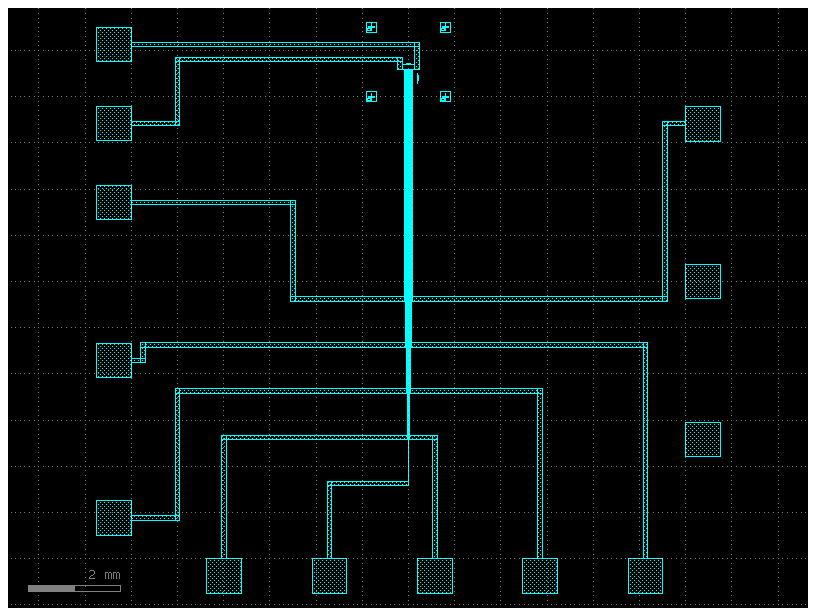

In [49]:
au = TC.extract(layers=[TFTClayers.AU_ACTIVE])
print("layer", TC.ports[1].layer)
au

layer NI_TC


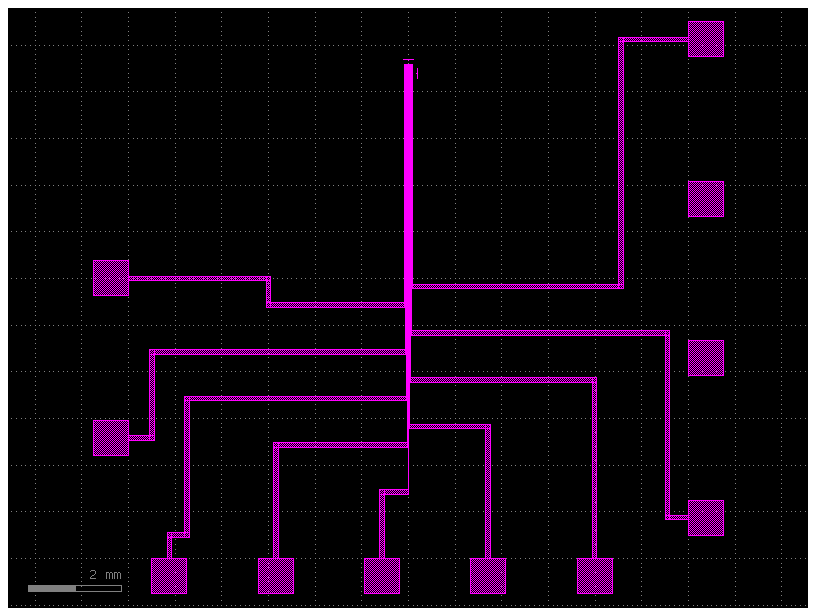

In [50]:
ni = TC.extract(layers=[TFTClayers.NI_TC])
print("layer", TC.ports[5].layer)
ni

## Overlap (Junctions) 

Au/Ni overlap: 36.0 um^2  (expected ~36 from 9 junctions of 2x2)


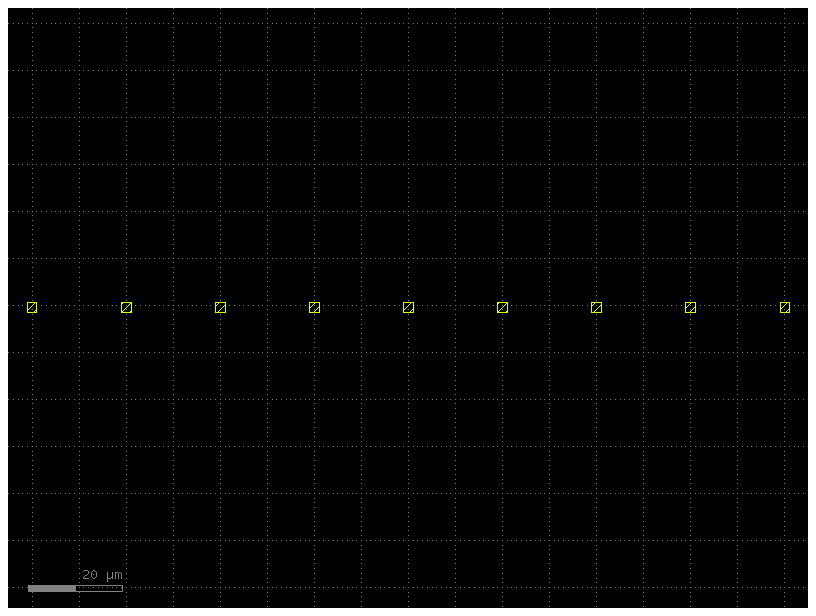

In [48]:
overlap = gf.boolean(au, ni, operation="and", layer=(99,0), layer1=TFTClayers.AU_ACTIVE, layer2=TFTClayers.NI_TC)
area = sum(p.area() for polys in overlap.get_polygons().values() for p in polys)
print(f"Au/Ni overlap: {area/1e6} um^2  (expected ~36 from 9 junctions of 2x2)")

overlap

# Stepped Heater for different junction temps

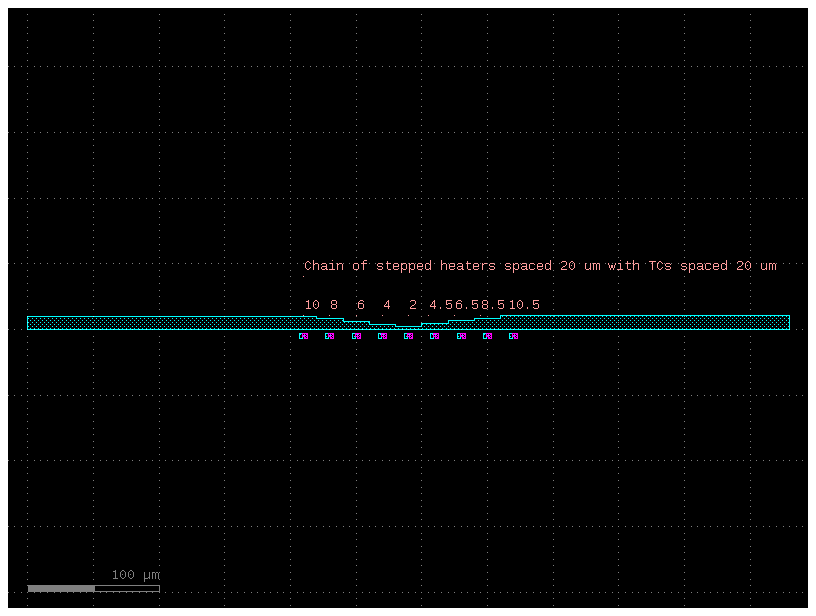

In [34]:
gf.clear_cache()

# blank component
heater = gf.Component("Stepped_Heater")

# 2. Define the original right-angled coordinates of the heater (Layer 1: Au layer)
stepped_heater_coords = [
    (-200.0, 0.0),
    (-200.0, 10.0),
    (20.0, 10.0),
    (20.0, 8.0),
    (40.0, 8.0),
    (40.0, 6.0),
    (60.0, 6.0),
    (60.0, 4.0),
    (80.0, 4.0),
    (80.0, 2.0),
    (100.0, 2.0),
    (100.0, 4.50),
    (120.0, 4.50),
    (120.0, 6.50),
    (140.0, 6.50),
    (140.0, 8.50),
    (160.0, 8.50),
    (160.0, 10.50),
    (180.0, 10.50),
    (380.0, 10.50),
    (380, 0),
    (-100, 0)
]

# Add poolygons to layers
p1 = heater.add_polygon(stepped_heater_coords, layer=TFTClayers.AU_ACTIVE)

# Spacing centers of TCs by 20 um
for i in range(9):
    tc = thermocouple_junction(w=2, text=False)
    tc_ref = heater << tc
    tc_ref.center = (10 + 20 *i, -5)

heater.add_label(text="10", position = (10, 11), layer = (0,0))
heater.add_label(text="8", position = (30, 11), layer = (0,0))
heater.add_label(text="6", position = (50, 11), layer = (0,0))
heater.add_label(text="4", position = (70, 11), layer = (0,0))
heater.add_label(text="2", position = (90, 11), layer = (0,0))
heater.add_label(text="4.5", position = (105, 11), layer = (0,0))
heater.add_label(text="6.5", position = (125, 11), layer = (0,0))
heater.add_label(text="8.5", position = (145, 11), layer = (0,0))
heater.add_label(text="10.5", position = (165, 11), layer = (0,0))

descriptor = "Chain of stepped heaters spaced 20 um with TCs spaced 20 um"
heater.add_label(text=descriptor, position = (10, 40), layer = (0,0))

heater.write_gds("sample_stepped_heater.gds")
heater.plot()

Just copying the above down and editing because its easier. Should just make a function for the heater assembly component and implement as part of the above

Side Pad Spacing: 958 um
Bottom Pad Spacing: 389 um


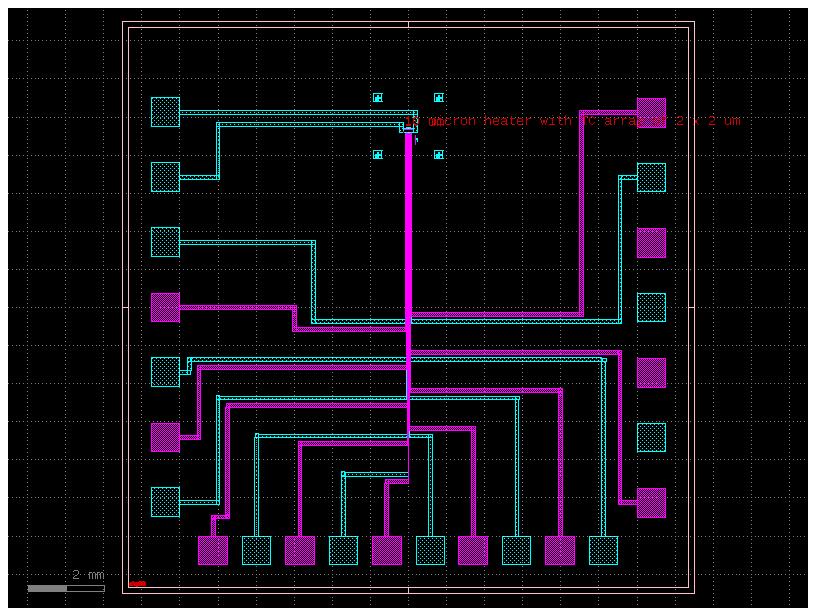

In [57]:
gf.clear_cache()
TC = gf.Component("Example combination of sample TC and Frame")

# ================= Frame ================= #
Frame = die(
    size=(15000, 15000),      # 15 mm x 15 mm
    street_width=150,         
    # die_name="15mm_ActiveRegion", 
    text_location="SW",       # text bottom left
    layer=TFTClayers.FLOORPLAN,
    bbox_layer="FLOORPLAN",
    draw_corners=False        
)
addFrame = TC.add_ref(Frame)

# ================= Contact Pads ================= #

port_dict = {}
contactpad_size = 750

alternate_layers = [TFTClayers.AU_ACTIVE, TFTClayers.NI_TC]
# Generate pad component definitions
for i in range(1, 25):
    if i <= 2: # heater pads
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=TFTClayers.AU_ACTIVE, port_width=100.0, port_orientation=0.0)
    elif i < 8: # every second layer
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=alternate_layers[(i+1) % 2], port_width=100.0, port_orientation=0.0)
    elif i < 18:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=alternate_layers[(i+1) % 2], port_width=100.0, port_orientation=90.0)
    else:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=alternate_layers[(i+1) % 2], port_width=100.0, port_orientation=180.0)
        
side_clearance = round((11000 - 7 * contactpad_size) / 6)
bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
bottom_x_offset = -5500
side_y_offset = 5500

print(f"Side Pad Spacing: {side_clearance} um\nBottom Pad Spacing: {bottom_clearance} um")

# Add pads as references and inherit ports to master component
add_port_dict = {}
for i in range(1, 25):
    ref = TC << port_dict[f"cp{i}"]
    add_port_dict[f"add_cp{i}"] = ref
    
    # Spread the contact pads evenly along each side: (1,7)Left, (8,17)Bottom, (18,24)Right
    if i < 8:
        ref.center = (-7500 + 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-1) - contactpad_size/2)
    elif i < 18: 
        ref.center = (bottom_x_offset + (bottom_clearance + contactpad_size) * (i-8) + contactpad_size/2, -7500 + 1.5 * contactpad_size)
    else:
        # ref.center = (7500 - 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-18) - contactpad_size/2)
        ref.center = (
        7500 - 1.5 * contactpad_size,
        -side_y_offset + (side_clearance + contactpad_size) * (i-18) + contactpad_size/2
    )

    # SUCCESS: Exposing pad ports up to the main master component
    TC.add_ports(ref.ports, prefix=f"pad_{i}_")


# ================= Heater Sub-Component ================= #
single_heater = gf.Component("Single_Heater")
descriptor = "10 micron heater with TC array of 2 x 2 um"

step_offset = 50
# Define the coordinates of the heater (Layer 1: Au layer)
heater_coords = [
    (-100.0, 0.0),
    (-100.0, 10.0),
    (20.0 + step_offset, 10.0),
    (20.0 + step_offset, 8.0),
    (40.0 + step_offset, 8.0),
    (40.0 + step_offset, 6.0),
    (60.0 + step_offset, 6.0),
    (60.0 + step_offset, 4.0),
    (80.0 + step_offset, 4.0),
    (80.0 + step_offset, 2.0),
    (100.0 + step_offset, 2.0),
    (100.0 + step_offset, 4.50),
    (120.0 + step_offset, 4.50),
    (120.0 + step_offset, 6.50),
    (140.0 + step_offset, 6.50),
    (140.0 + step_offset, 8.50),
    (160.0 + step_offset, 8.50),
    (160.0 + step_offset, 10.50),
    (180.0 + step_offset, 10.50),
    (380.0, 10.50),
    (380, 0),
    (-100, 0)
]

# Add polygon to heater (stepped_heater_coords for stepped heater)
p1 = single_heater.add_polygon(heater_coords, layer=TFTClayers.AU_ACTIVE)

# 10 um port on either side of the heater trace
single_heater.add_port(
    name="v_in",
    center=(-50, 10),
    width=100,
    orientation=90,
    layer=TFTClayers.AU_ACTIVE,
    port_type="electrical"
)

single_heater.add_port(
    name="v_out",
    center=(330, 10),
    width=100,
    orientation=90,
    layer=TFTClayers.AU_ACTIVE,
    port_type="electrical"
)

# ================= Thermocouples Sub-Component ================= #
# Instantiate and space 9 Thermocouple Junctions by 20 um
# separation is just for routing connecting lines (if statements?)
# Making the TC's single layer. To adjust chance layer_top = (i+2, 0) which makes a new layer for each TC for multi thickness tests.
# NOTE: Adjusting the offset on the TCs also moves the heater up !!!!!
for i in range(9):
    if i < 5:    
        tc_leg_offset = 5000 + 1000 * i
        differential_offset = 200
        tc = thermocouple_junction(w=2, layer_top = TFTClayers.NI_TC, text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset)
    else:
        tc_leg_offset = 5000 + 1000 * (8-i)
        differential_offset = -200
        tc = thermocouple_junction(w=2, layer_top = TFTClayers.NI_TC, text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset, port_orientation=180)
    tc_ref = single_heater << tc
    if i < 5:
        # offset 8.5 for stepped heater not 60 (60 is arbitrary)
        tc_ref.center = (60 + 20 *i, - 5 - (tc_leg_offset + differential_offset)/2)
    else:
        # The differential is because its now shorter not longer than the offset
        tc_ref.center = (60 + 20 *i, - 5 + differential_offset/2 - (tc_leg_offset + differential_offset)/2)

    # REmember to inherit the PORTS!!! I keep forgetting!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

single_heater.add_label(text="10 um", position=(10, 11), layer=TFTClayers.TEXT)
single_heater.add_label(text=descriptor, position=(10, 40), layer=TFTClayers.TEXT)


# ================= Heater Assembly ================= #
heater_ref = TC << single_heater
heater_ref.center = (0, 0) # Placing it perfectly dead-center of your 15mm frame

# Inherit the heater and sub-TC ports up to the master structure as well
TC.add_ports(heater_ref.ports, prefix="heater_")

# ================= Routing (route_single, per-route optional waypoints) ================= #
route_width = 100.0   # fixed (100 microns

# ROUTES: name: (layer, pad_port, device_port, waypoints)
#   waypoints = [(x,y), ...] OR None  => forced routing OR Auto routing
ROUTES = {
    "heat_in":  (TFTClayers.AU_ACTIVE, "pad_2_e1",  "heater_v_in", 
        [(-6000.0, 3417.0), 
         (-5000.0, 3417.0), 
         (-5000.0, 4800), 
         (-190.0, 4800), 
         (-190.0, 4593.5)
        ]),
    "heat_out": (TFTClayers.AU_ACTIVE, "pad_1_e1",  "heater_v_out", 
        [(-6000.0, 5125.0), 
         (190.0, 5125.0), 
         (190.0, 4593.5)]
        ),
    "tc0_au": (TFTClayers.AU_ACTIVE, "pad_3_e1",  "heater_tc_0_e1_gold", 
        [(-6000.0, 1709.0), 
         (-2500.0, 1709.0), 
         (-2500.0, -373.5), 
         (-83.0, -373.5)]
        ), 
    "tc0_ni": (TFTClayers.NI_TC,     "pad_4_e1",  "heater_tc_0_e2_nickel", 
        [(-6000.0, 1.0), 
         (-3000.0, 1.0), 
         (-3000.0, -573.5), 
         (-79.0, -573.5)]
        ), 
    "tc1_au": (TFTClayers.AU_ACTIVE, "pad_5_e1",  "heater_tc_1_e1_gold", 
        [(-6000.0, -1707.0), 
         (-5750.0, -1707.0), 
         (-5750.0, -1373.5), 
         (-63.0, -1373.5)]
        ),
    "tc1_ni": (TFTClayers.NI_TC,     "pad_6_e1",  "heater_tc_1_e2_nickel", 
        [(-6000.0, -3415.0), 
         (-5500.0, -3415.0), 
         (-5500.0, -1573.5), 
         (-59.0, -1573.5)]
        ), 
    "tc2_au": (TFTClayers.AU_ACTIVE, "pad_7_e1",  "heater_tc_2_e1_gold",
        [(-6000.0, -5123.0), 
         (-5000.0, -5123.0), 
         (-5000.0, -2373.5), 
         (-43.0, -2373.5)]
        ), 
    "tc2_ni": (TFTClayers.NI_TC,     "pad_8_e1",  "heater_tc_2_e2_nickel", 
        [(-5125.0, -6000.0), 
         (-5125.0, -5500.0), 
         (-4750.0, -5500.0), 
         (-4750.0, -2573.5),
         (-39.0, -2573.5)]
        ),
    "tc3_au": (TFTClayers.AU_ACTIVE, "pad_9_e1",  "heater_tc_3_e1_gold",   None), # OK
    "tc3_ni": (TFTClayers.NI_TC,     "pad_10_e1", "heater_tc_3_e2_nickel", None), # OK
    "tc4_au": (TFTClayers.AU_ACTIVE, "pad_11_e1", "heater_tc_4_e1_gold",   None), # OK
    "tc4_ni": (TFTClayers.NI_TC,     "pad_12_e1", "heater_tc_4_e2_nickel", None), # OK
    "tc5_au": (TFTClayers.AU_ACTIVE, "pad_13_e1", "heater_tc_5_e1_gold",   None), # OK
    "tc5_ni": (TFTClayers.NI_TC,     "pad_14_e1", "heater_tc_5_e2_nickel", None), # OK
    "tc6_au": (TFTClayers.AU_ACTIVE, "pad_15_e1", "heater_tc_6_e1_gold",   None), # OK
    "tc6_ni": (TFTClayers.NI_TC,     "pad_16_e1", "heater_tc_6_e2_nickel", None), # OK
    "tc7_au": (TFTClayers.AU_ACTIVE, "pad_17_e1", "heater_tc_7_e1_gold",   None), # OK
    "tc7_ni": (TFTClayers.NI_TC,     "pad_18_e1", "heater_tc_7_e2_nickel", 
        [(6000.0, -5125.0), 
         (5550.0, -5125.0), 
         (5550.0, -1173.5), 
         (63.0, -1173.5)]
        ),
    "tc8_au": (TFTClayers.AU_ACTIVE, "pad_23_e1", "heater_tc_8_e1_gold", 
        [(6000.0, 3415.0), 
         (5550.0, 3415.0), 
         (5550.0, -373.5), 
         (79.0, -373.5)]
        ), 
    "tc8_ni": (TFTClayers.NI_TC,     "pad_24_e1", "heater_tc_8_e2_nickel", 
        [(6000.0, 5123.0), 
         (4550.0, 5123.0), 
         (4550.0, -173.5), 
         (83.0, -173.5)]
        ), 
}

routes = {}  # store routes to take them out later to copy above. 
for name, (layer, pad_name, dev_name, waypoints) in ROUTES.items():
    kwargs = dict(
        port1=TC.ports[pad_name],
        port2=TC.ports[dev_name],
        cross_section=tftc_metal_route(width=route_width, layer=layer),
        bend="wire_corner",
        port_type="electrical",
        allow_width_mismatch=True,
    )
    if waypoints is not None:
        kwargs["waypoints"] = [gf.kdb.DPoint(x, y) for x, y in waypoints]
    try:
        routes[name] = gf.routing.route_single(TC, **kwargs)
    except Exception as e:
        print(f"!! route '{name}' failed: {e}")

# ========================= Adding Calipers in X and Y around the junction to check alignment ========================= #

# Adding Calipers to verify alignment between layers. 
x_cal = litho_calipers(notch_size=(5.0, 10.0), notch_spacing=5.0, layer1=TFTClayers.AU_ACTIVE, layer2=TFTClayers.NI_TC)
y_cal = litho_calipers(notch_size=(5.0, 10.0), notch_spacing=5.0, layer1=TFTClayers.AU_ACTIVE, layer2=TFTClayers.NI_TC)

add_x_cal = TC << x_cal
add_x_cal.center = (0,4700)

add_y_cal = TC << y_cal
add_y_cal.rotate(270)
add_y_cal.center = (200, 4400)


# ========================= Alignment Markers ========================= #

markers = gf.Component(name="Alignment_markers")

mark_1 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")
mark_2 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")
mark_3 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")
mark_4 = markers << gf.components.align_wafer(width=20, spacing=20, cross_length=150, layer=TFTClayers.AU_ACTIVE, square_corner="bottom_left")

mark_1.movex(800).movey(5500)
mark_2.movex(800).movey(4000)
mark_3.movex(-800).movey(5500)
mark_4.movex(-800).movey(4000)
_ = TC << markers

# ========================= Saving / displaying GDS file ========================== #
TC.write_gds("IntegratedTCArray_SteppedHeater.gds")
# TC.draw_ports() # ports
TC.plot()

# Multilyaer structure for testing different thicknesses

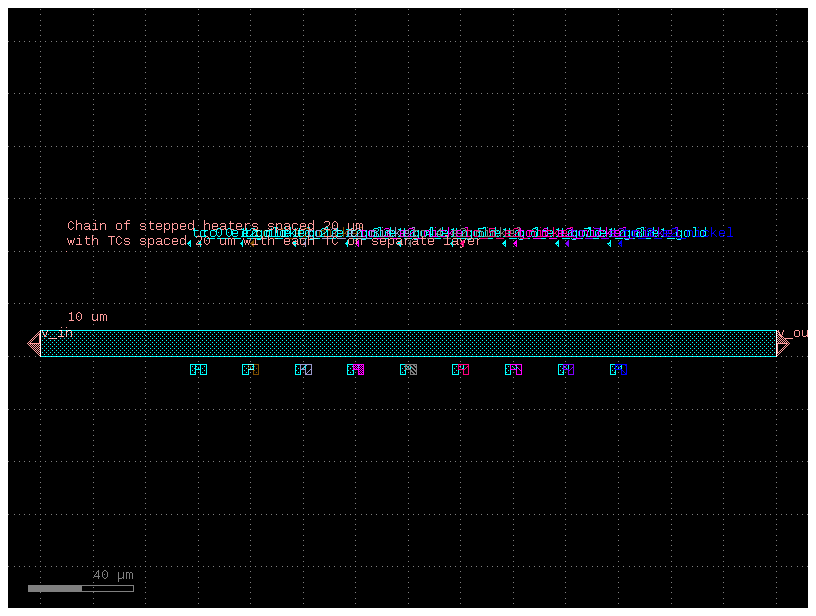

In [35]:
gf.clear_cache()

# blank component
single_heater = gf.Component("Single_Heater")

# 2. Define the original right-angled coordinates of the heater (Layer 1: Au layer)
coords_layer1 = [
    (0.0, 0.0),
    (0.0, 10.0),
    (280.0, 10.0),
    (280, 0),
    (0, 0)
]

# Add poolygons to layers
p1 = single_heater.add_polygon(coords_layer1, layer=TFTClayers.AU_ACTIVE)

# 10 um port either side
single_heater.add_port(name="v_in",
    center=(0.0, 5),
    width=10,
    orientation=180,
    layer=(1,0),
    port_type="electrical"
)

single_heater.add_port(name="v_out",
    center=(280, 5),
    width=10,
    orientation=0,
    layer=(1,0),
    port_type="electrical"
)

# Spacing centers of TCs by 20 um
for i in range(9):
    tc = thermocouple_junction(w=2, layer_top = (i+2,0), text=False)
    tc_ref = single_heater << tc
    tc_ref.center = (60 + 20 *i, -5)

    # Inherit TC ports. This is important!!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

    # referenced as single_heater.ports["tc_0_e1_gold"] etc.

single_heater.add_label(text="10 um", position = (10, 11), layer = (0,0))

descriptor = "Chain of stepped heaters spaced 20 um\nwith TCs spaced 20 um with each TC on separate layer"
single_heater.add_label(text=descriptor, position = (10, 40), layer = (0,0))

single_heater.write_gds("sample_multi_layer_TCs.gds")
single_heater.draw_ports()
single_heater.plot()

# Stepped Heater with multilayer tftc array

Side Pad Spacing: 958 um
Bottom Pad Spacing: 389 um


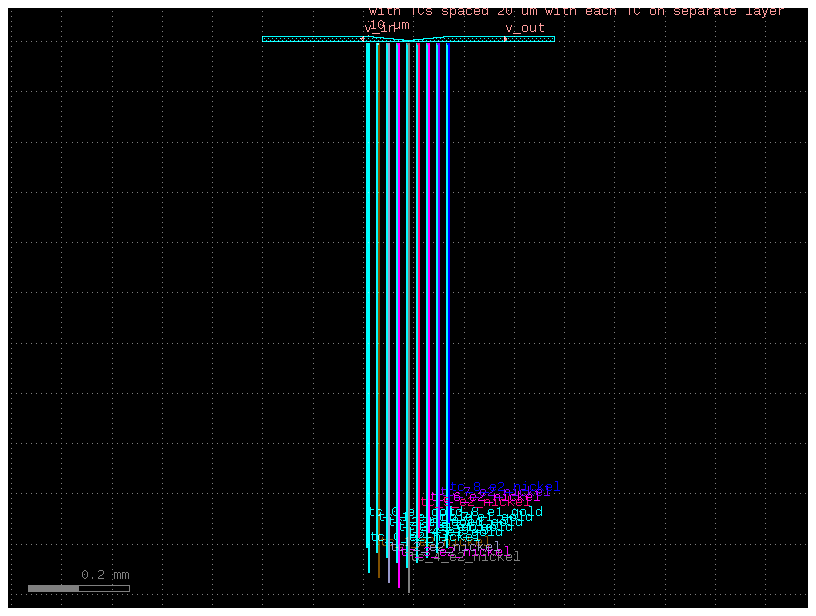

In [36]:
gf.clear_cache()

# Main Component. All components above will be added here. 
TC = gf.Component("Example combination of sample TC and Frame")

# ====================== 15 x 15 Frame ====================== #

# Components to add to main component
Frame = die(
    size=(15000, 15000),      # 15 mm x 15 mm
    street_width=150,         
    die_name="15mm_ActiveRegion", 
    text_location="SW",       # text bottom left
    layer="FLOORPLAN",
    bbox_layer="FLOORPLAN",
    draw_corners=False        
)
addFrame = TC.add_ref(Frame)

# ====================== Contact Pads ====================== #
# Creating Contact pads assigned to each layer with ports oriented per PCB design. 
# need to add power and ground to bottom layer and then every second one to Au/Ni layers. 
# layer setting is mod 2 so every second one is on a different layer.
port_dict = {}
contactpad_size = 750
for i in range(1,25):
    if i <= 2:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=(1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 8:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 18:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=90.0)
    else:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=180.0)
        
side_clearance =  round((11000 - 7 * contactpad_size) / 6)
bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
bottom_x_offset = -5500
side_y_offset = 5500

print(f"Side Pad Spacing: {side_clearance} um\nBottom Pad Spacing: {bottom_clearance} um")

# Adding directional ports to the contact pads
add_port_dict = {}
for i in range(1,25):
    add_port_dict[f"add_cp{i}"] = TC << port_dict[f"cp{i}"]
    # Here, I need to spread the contact pads evenly along each side. (1,7)L, (8,17)B, (18,24)R
    if i < 8:
        add_port_dict[f"add_cp{i}"].center = (-7500 + 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-1) - contactpad_size/2)
    elif i < 18: 
        add_port_dict[f"add_cp{i}"].center = (bottom_x_offset + (bottom_clearance + contactpad_size) * (i-8) + contactpad_size/2, -7500 + 1.5 * contactpad_size)
    else:
        add_port_dict[f"add_cp{i}"].center = (7500 - 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-18)  -contactpad_size/2)

# ======================= Adding TCs ======================= #

single_heater = gf.Component("Single_Heater")
descriptor = "Chain of stepped heaters spaced 20 um\nwith TCs spaced 20 um with each TC on separate layer"

# 2. Define the original right-angled coordinates of the heater (Layer 1: Au layer)
heater_coords = [
    (0.0, 0.0),
    (0.0, 10.0),
    (280.0, 10.0),
    (280, 0),
    (0, 0)
]

# Add poolygons to layers
p1 = single_heater.add_polygon(stepped_heater_coords, layer=TFTClayers.AU_ACTIVE)

# 10 um port either side
single_heater.add_port(name="v_in",
    center=(0.0, 5),
    width=10,
    orientation=180,
    layer=(1,0),
    port_type="electrical"
)

single_heater.add_port(name="v_out",
    center=(280, 5),
    width=10,
    orientation=0,
    layer=(1,0),
    port_type="electrical"
)

# Spacing centers of TCs by 20 um

for i in range(9):
    if i < 5:    
        tc_leg_offset = 1000 + 10 * i
        differential_offset = 50
    else:
        tc_leg_offset = 1000 + 10 * (8-i)
        differential_offset = -50
    tc = thermocouple_junction(w=2, layer_top = (i+2,0), text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset)
    tc_ref = single_heater << tc
    if i < 5:
        tc_ref.center = (8.5 + 20 *i, - 5 - (tc_leg_offset + differential_offset)/2)
    else:
        # The differential is because its now shorter not longer than the offset
        tc_ref.center = (8.5 + 20 *i, - 5 + differential_offset/2 - (tc_leg_offset + differential_offset)/2)

    # REmember to inherit the PORTS!!! I keep forgetting!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

single_heater.add_label(text="10 um", position = (10, 11), layer = (0,0))
single_heater.add_label(text=descriptor, position = (10, 40), layer = (0,0))

single_heater.write_gds("sample_multi_layer_stepped_heater_TCs.gds")
single_heater.draw_ports()
single_heater.plot()